In [1]:
import os
import time
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

# Fix: Keras 3 + protobuf can crash in this environment; use tf_keras (installed) for stability.
from tf_keras.models import Sequential
from tf_keras.layers import Dense, Conv2D, Dropout, MaxPooling2D, Flatten
from tf_keras.callbacks import EarlyStopping

# Kaggle-style input discovery (keep as close as possible to original intent)
base_input = "/kaggle/input"
if os.path.exists(base_input):
    print("Available datasets in /kaggle/input:", os.listdir(base_input)[:20])



2026-01-10 21:30:28.501060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768080628.514860      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768080628.519224      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-10 21:30:28.536156: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Available datasets in /kaggle/input: ['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


In [2]:
# Fix: Correct dataset paths for this competition.
# The provided filesystem shows the competition data under /kaggle/input/aerial-cactus-identification/...
DATA_DIR = "/kaggle/input/aerial-cactus-identification"
train_path = os.path.join(DATA_DIR, "train")
test_path = os.path.join(DATA_DIR, "test")
train_csv_path = os.path.join(DATA_DIR, "train.csv")
sample_sub_path = os.path.join(DATA_DIR, "sample_submission.csv")

print("train_path:", train_path, "exists:", os.path.isdir(train_path))
print("test_path:", test_path, "exists:", os.path.isdir(test_path))
print("train_csv_path:", train_csv_path, "exists:", os.path.isfile(train_csv_path))
print("sample_sub_path:", sample_sub_path, "exists:", os.path.isfile(sample_sub_path))



train_path: /kaggle/input/aerial-cactus-identification/train exists: True
test_path: /kaggle/input/aerial-cactus-identification/test exists: True
train_csv_path: /kaggle/input/aerial-cactus-identification/train.csv exists: True
sample_sub_path: /kaggle/input/aerial-cactus-identification/sample_submission.csv exists: True


In [3]:
# Fix: Align labels with images by mapping id->label, not by a counter.
# Also fix: guard against cv2.imread returning None (corrupt/missing file), which caused NoneType shape errors later.
label_train = pd.read_csv(train_csv_path).sort_values(by=["id"]).reset_index(drop=True)
id_to_label = dict(
    zip(label_train["id"].values, label_train["has_cactus"].values.astype(np.float32))
)

X_list, Y_list = [], []
missing_in_csv = 0
unreadable = 0

train_files = sorted(os.listdir(train_path))
for fname in tqdm(train_files, desc="Loading train images"):
    if fname not in id_to_label:
        missing_in_csv += 1
        continue
    img = cv2.imread(os.path.join(train_path, fname), cv2.IMREAD_COLOR)
    if img is None:
        unreadable += 1
        continue
    # Safety: enforce expected shape (32,32,3) to keep model input consistent
    if img.shape != (32, 32, 3):
        img = cv2.resize(img, (32, 32), interpolation=cv2.INTER_AREA)
    X_list.append(img)
    Y_list.append(id_to_label[fname])

print("Train files:", len(train_files))
print(
    "Loaded train images:",
    len(X_list),
    "| missing_in_csv:",
    missing_in_csv,
    "| unreadable:",
    unreadable,
)

X = np.asarray(X_list, dtype=np.float32) / 255.0
Y = np.asarray(Y_list, dtype=np.float32)

print("X shape:", X.shape, "Y shape:", Y.shape)



Loading train images: 100%|██████████| 14176/14176 [00:01<00:00, 8821.58it/s]


Train files: 14176
Loaded train images: 14175 | missing_in_csv: 1 | unreadable: 0
X shape: (14175, 32, 32, 3) Y shape: (14175,)


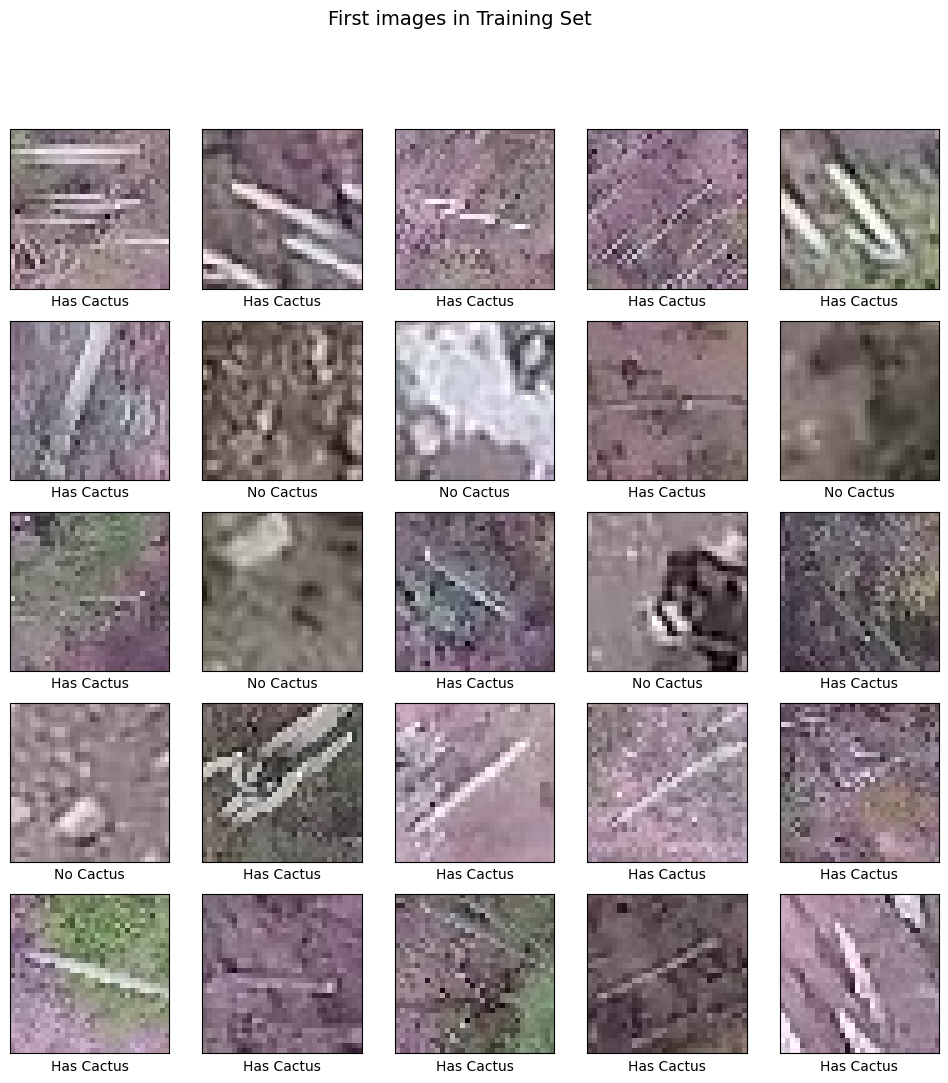

In [4]:
# Visualization (keep behavior; ensure it doesn't crash if fewer than 25 samples)
plt.figure(figsize=(12, 12))
n_show = min(25, len(Y))
for i in range(n_show):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    lbl = "Has Cactus" if Y[i] == 1 else "No Cactus"
    plt.xlabel(lbl, fontsize=10)
    # OpenCV loads BGR; matplotlib expects RGB
    plt.imshow(cv2.cvtColor((X[i] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.suptitle("First images in Training Set", fontsize=14)
plt.show()



In [5]:
# Fix: Load test images into a homogeneous numpy array by using a list then stacking,
# and ensure deterministic sorted order matching submission ids.
X_test_list = []
test_ids = []

test_files = sorted(os.listdir(test_path))
unreadable_test = 0

for fname in tqdm(test_files, desc="Loading test images"):
    img = cv2.imread(os.path.join(test_path, fname), cv2.IMREAD_COLOR)
    if img is None:
        unreadable_test += 1
        continue
    if img.shape != (32, 32, 3):
        img = cv2.resize(img, (32, 32), interpolation=cv2.INTER_AREA)
    X_test_list.append(img)
    test_ids.append(fname)

print(
    "Test files:",
    len(test_files),
    "| loaded:",
    len(X_test_list),
    "| unreadable:",
    unreadable_test,
)

X_test = np.asarray(X_test_list, dtype=np.float32) / 255.0
print("X_test shape:", X_test.shape)



Loading test images: 100%|██████████| 3326/3326 [00:00<00:00, 9730.27it/s]

Test files: 3326 | loaded: 3325 | unreadable: 1
X_test shape: (3325, 32, 32, 3)


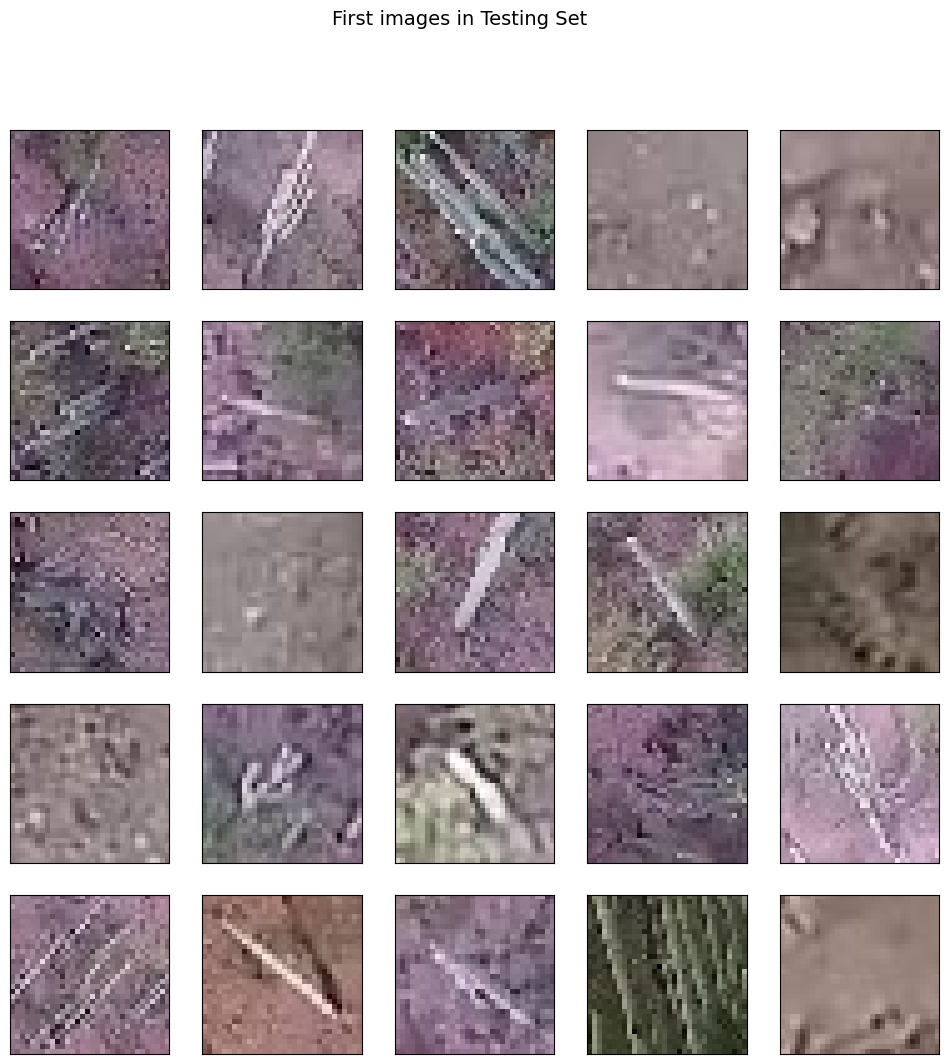

In [6]:
# Visualization (keep behavior; ensure it doesn't crash)
plt.figure(figsize=(12, 12))
n_show = min(25, len(X_test))
for i in range(n_show):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(cv2.cvtColor((X_test[i] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.suptitle("First images in Testing Set", fontsize=14)
plt.show()



In [7]:
# Model definition (kept identical to original net1 architecture)
m = Sequential()
m.add(
    Conv2D(
        filters=128,
        kernel_size=2,
        padding="same",
        activation="relu",
        input_shape=(32, 32, 3),
    )
)
m.add(MaxPooling2D(pool_size=2, strides=1))
m.add(Dropout(0.2))
m.add(Conv2D(filters=64, kernel_size=2, padding="same", activation="relu"))
m.add(MaxPooling2D(pool_size=2, strides=1))
m.add(Dropout(0.2))
m.add(Conv2D(filters=32, kernel_size=2, padding="same", activation="relu"))
m.add(MaxPooling2D(pool_size=2, strides=1))
m.add(Dropout(0.2))
m.add(Flatten())
m.add(Dense(32, activation="relu"))
m.add(Dropout(0.7))
m.add(Dense(1, activation="sigmoid"))
m.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 128)       1664      
                                                                 
 max_pooling2d (MaxPooling2  (None, 31, 31, 128)       0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 31, 31, 128)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 31, 31, 64)        32832     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 30, 30, 64)        0

2026-01-10 21:30:38.150376: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768080638.150805      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


In [8]:
# Training (same core settings; just ensure data is valid and avoid NoneType issues)
el = EarlyStopping(min_delta=0.001, patience=5, restore_best_weights=True)

m.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

s = time.time()
h = m.fit(
    X, Y, batch_size=256, validation_split=0.2, epochs=100, callbacks=[el], verbose=2
)
e = time.time()
t = e - s
print("Addestramento completato in %d minuti e %d secondi" % (t / 60, t % 60))



Epoch 1/100


E0000 00:00:1768080639.055696      11 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1768080639.140086      68 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1768080640.216208      66 service.cc:148] XLA service 0x7f498cdf3d50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768080640.216232      66 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-10 21:30:40.221328: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768080640.285563      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


45/45 - 4s - loss: 0.5165 - accuracy: 0.7333 - val_loss: 0.3440 - val_accuracy: 0.7524 - 4s/epoch - 81ms/step
Epoch 2/100
45/45 - 1s - loss: 0.3060 - accuracy: 0.8408 - val_loss: 0.3175 - val_accuracy: 0.9178 - 748ms/epoch - 17ms/step
Epoch 3/100
45/45 - 1s - loss: 0.2865 - accuracy: 0.9106 - val_loss: 0.2475 - val_accuracy: 0.9369 - 745ms/epoch - 17ms/step
Epoch 4/100
45/45 - 1s - loss: 0.2816 - accuracy: 0.9076 - val_loss: 0.2714 - val_accuracy: 0.9093 - 746ms/epoch - 17ms/step
Epoch 5/100
45/45 - 1s - loss: 0.2474 - accuracy: 0.9155 - val_loss: 0.2242 - val_accuracy: 0.9407 - 752ms/epoch - 17ms/step
Epoch 6/100
45/45 - 1s - loss: 0.2220 - accuracy: 0.9257 - val_loss: 0.1656 - val_accuracy: 0.9608 - 749ms/epoch - 17ms/step
Epoch 7/100
45/45 - 1s - loss: 0.2183 - accuracy: 0.9249 - val_loss: 0.1446 - val_accuracy: 0.9668 - 748ms/epoch - 17ms/step
Epoch 8/100
45/45 - 1s - loss: 0.2125 - accuracy: 0.9253 - val_loss: 0.2438 - val_accuracy: 0.9086 - 745ms/epoch - 17ms/step
Epoch 9/100
45/

In [9]:
# Fix: Keras history keys are 'accuracy'/'val_accuracy' in modern Keras/tf_keras.
acc = h.history.get("accuracy", [])
val_acc = h.history.get("val_accuracy", [])
loss = h.history.get("loss", [])
val_loss = h.history.get("val_loss", [])

print("History keys:", list(h.history.keys()))



History keys: ['loss', 'accuracy', 'val_loss', 'val_accuracy']


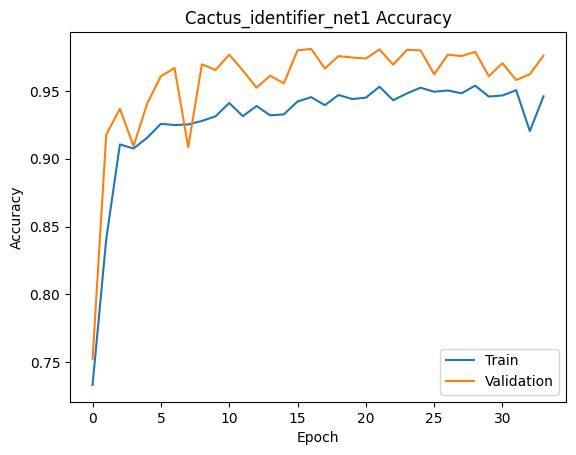

In [10]:
plt.plot(acc)
plt.plot(val_acc)
plt.title("Cactus_identifier_net1 Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()



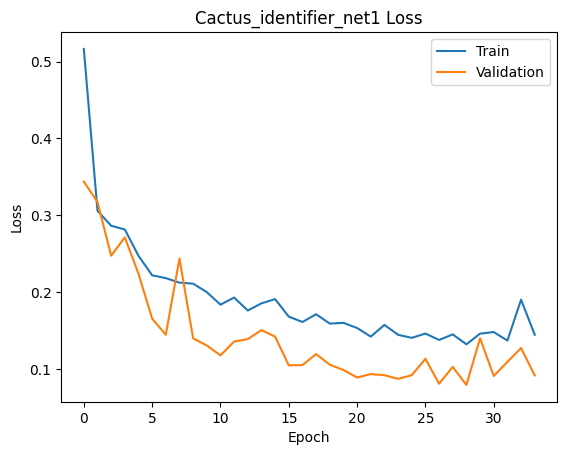

In [11]:
plt.plot(loss)
plt.plot(val_loss)
plt.title("Cactus_identifier_net1 Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()



In [12]:
# Fix: Predict safely and produce a valid submission with correct id alignment and length.
pred = m.predict(X_test, batch_size=256, verbose=0).reshape(-1)

pred_df = pd.DataFrame({"id": test_ids, "has_cactus": pred.astype(np.float64)})

# Ensure submission matches sample_submission ids/order exactly
sample_sub = pd.read_csv(sample_sub_path)
sub = sample_sub[["id"]].merge(pred_df, on="id", how="left")

# If any ids were unreadable and thus missing predictions, fill with 0.5 (neutral) to keep valid file.
sub["has_cactus"] = sub["has_cactus"].astype(float).fillna(0.5)

out_path = "cactus_identifier_net1.csv"
sub.to_csv(out_path, index=False, header=True)

print("Wrote submission:", out_path)
print(sub.head())
print(
    "Submission shape:",
    sub.shape,
    "| missing preds filled:",
    int(sub["has_cactus"].isna().sum()),
)



Wrote submission: cactus_identifier_net1.csv
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    0.999989
1  134f04305c795d6d202502c2ce3578f3.jpg    1.000000
2  41fad8d145e6c41868ce3617e30a2545.jpg    1.000000
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.999954
4  b77dc902b035887cbbc01920ce0e3151.jpg    1.000000
Submission shape: (3325, 2) | missing preds filled: 0


In [13]:
# Keep the alternative model definitions from the original notebook (net2), but do not execute training again by default.
# This preserves original structure without changing the primary end-to-end pipeline.
m2 = Sequential()
m2.add(
    Conv2D(
        filters=128,
        kernel_size=2,
        padding="same",
        activation="relu",
        input_shape=(32, 32, 3),
    )
)
m2.add(MaxPooling2D(pool_size=2, strides=1))
m2.add(Dropout(0.2))
m2.add(Conv2D(filters=64, kernel_size=2, padding="same", activation="relu"))
m2.add(MaxPooling2D(pool_size=2, strides=1))
m2.add(Dropout(0.2))
m2.add(Conv2D(filters=32, kernel_size=2, padding="same", activation="relu"))
m2.add(MaxPooling2D(pool_size=2, strides=1))
m2.add(Dropout(0.2))
m2.add(Flatten())
m2.add(Dense(64, activation="relu"))
m2.add(Dropout(0.5))
m2.add(Dense(1, activation="sigmoid"))
m2.summary()



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 32, 32, 128)       1664      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 31, 31, 128)       0         
 g2D)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 31, 31, 128)       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 31, 31, 64)        32832     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 dropout_5 (Dropout)         (None, 30, 30, 64)       

In [14]:
# Optional: training net2 (disabled to keep runtime bounded and focus on producing one valid submission)
# To enable, set RUN_NET2 = True
RUN_NET2 = False
if RUN_NET2:
    el2 = EarlyStopping(min_delta=0.001, patience=10, restore_best_weights=True)
    m2.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    s = time.time()
    h2 = m2.fit(
        X,
        Y,
        batch_size=256,
        validation_split=0.2,
        epochs=100,
        callbacks=[el2],
        verbose=2,
    )
    e = time.time()
    t = e - s
    print("Addestramento completato in %d minuti e %d secondi" % (t / 60, t % 60))



In [15]:
# Placeholder cell to preserve numbering; only runs if net2 trained
if RUN_NET2:
    acc2 = h2.history.get("accuracy", [])
    val_acc2 = h2.history.get("val_accuracy", [])
    loss2 = h2.history.get("loss", [])
    val_loss2 = h2.history.get("val_loss", [])



In [16]:
if RUN_NET2:
    plt.plot(acc2)
    plt.plot(val_acc2)
    plt.title("Cactus_identifier_net2 Accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"])
    plt.show()



In [17]:
if RUN_NET2:
    plt.plot(loss2)
    plt.plot(val_loss2)
    plt.title("Cactus_identifier_net2 Loss")
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"])
    plt.show()



In [18]:
# Optional net2 submission (disabled by default)
if RUN_NET2:
    pred2 = m2.predict(X_test, batch_size=256, verbose=0).reshape(-1)
    pred_df2 = pd.DataFrame({"id": test_ids, "has_cactus": pred2.astype(np.float64)})
    sub2 = sample_sub[["id"]].merge(pred_df2, on="id", how="left")
    sub2["has_cactus"] = sub2["has_cactus"].astype(float).fillna(0.5)
    out_path2 = "cactus_identifier_net2.csv"
    sub2.to_csv(out_path2, index=False, header=True)
    print("Wrote submission:", out_path2)



In [19]:
# Keep the original net3 definition as well (not trained by default)
m3 = Sequential()
m3.add(
    Conv2D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu",
        input_shape=(32, 32, 3),
    )
)
m3.add(MaxPooling2D(pool_size=2, strides=1))
m3.add(Dropout(0.2))
m3.add(Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"))
m3.add(MaxPooling2D(pool_size=2, strides=1))
m3.add(Dropout(0.2))
m3.add(Conv2D(filters=32, kernel_size=3, padding="same", activation="relu"))
m3.add(MaxPooling2D(pool_size=2, strides=1))
m3.add(Dropout(0.2))
m3.add(Conv2D(filters=16, kernel_size=3, padding="same", activation="relu"))
m3.add(MaxPooling2D(pool_size=2, strides=1))
m3.add(Dropout(0.2))
m3.add(Flatten())
m3.add(Dense(256, activation="relu"))
m3.add(Dense(128, activation="relu"))
m3.add(Dense(64, activation="relu"))
m3.add(Dense(32, activation="relu"))
m3.add(Dropout(0.4))
m3.add(Dense(1, activation="sigmoid"))
m3.summary()



Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 32, 32, 128)       3584      
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 31, 31, 128)       0         
 g2D)                                                            
                                                                 
 dropout_8 (Dropout)         (None, 31, 31, 128)       0         
                                                                 
 conv2d_7 (Conv2D)           (None, 31, 31, 64)        73792     
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 dropout_9 (Dropout)         (None, 30, 30, 64)       

In [20]:
# Optional: training net3 (disabled by default)
RUN_NET3 = False
if RUN_NET3:
    el3 = EarlyStopping(min_delta=0.001, patience=10, restore_best_weights=True)
    m3.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    s = time.time()
    h3 = m3.fit(
        X,
        Y,
        batch_size=512,
        validation_split=0.2,
        epochs=100,
        callbacks=[el3],
        verbose=2,
    )
    e = time.time()
    t = e - s
    print("Addestramento completato in %d minuti e %d secondi" % (t / 60, t % 60))



In [21]:
if RUN_NET3:
    acc3 = h3.history.get("accuracy", [])
    val_acc3 = h3.history.get("val_accuracy", [])
    loss3 = h3.history.get("loss", [])
    val_loss3 = h3.history.get("val_loss", [])



In [22]:
if RUN_NET3:
    plt.plot(acc3)
    plt.plot(val_acc3)
    plt.title("Cactus_identifier_net3 Accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"])
    plt.show()



In [23]:
if RUN_NET3:
    plt.plot(loss3)
    plt.plot(val_loss3)
    plt.title("Cactus_identifier_net3 Loss")
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"])
    plt.show()



In [24]:
# Optional net3 submission (disabled by default)
if RUN_NET3:
    pred3 = m3.predict(X_test, batch_size=256, verbose=0).reshape(-1)
    pred_df3 = pd.DataFrame({"id": test_ids, "has_cactus": pred3.astype(np.float64)})
    sub3 = sample_sub[["id"]].merge(pred_df3, on="id", how="left")
    sub3["has_cactus"] = sub3["has_cactus"].astype(float).fillna(0.5)
    out_path3 = "cactus_identifier_net3.1.csv"
    sub3.to_csv(out_path3, index=False, header=True)
    print("Wrote submission:", out_path3)